In [2]:
import pandas as pd

In [3]:
df=pd.read_excel("shihara_final_dataset.xlsx")

In [4]:
print(type(df))


<class 'pandas.core.frame.DataFrame'>


In [5]:
df.head()

,Date,Particulars,Payments,Receipts,Balance
0,2022-12-27,IB CEFT CHGS K A Kumaranayek,30.0,NaN,8449.35
1,2022-12-27,PURCHASE UNIVERSITY GRANTS C,50.0,NaN,8399.35
2,2022-12-28,PURCHASE KEELLS SUPER - MORA,5000.0,NaN,3399.35
3,2022-12-30,INTEREST,NaN,41.57,3440.92
4,2023-01-04,NOV RENT,NaN,75000.00,78440.92


In [6]:
df_balance=df[["Date","Balance"]].copy()

In [7]:
df_balance=df_balance.drop(0)

In [8]:
df_balance['Date']=pd.to_datetime(df_balance['Date'])

In [9]:
print(df_balance.dtypes)

Date       datetime64[ns]
Balance           float64
dtype: object


In [10]:
print(df_balance.head())

        Date   Balance
1 2022-12-27   8399.35
2 2022-12-28   3399.35
3 2022-12-30   3440.92
4 2023-01-04  78440.92
5 2023-01-04  75440.92


In [11]:
df_balance=df_balance.groupby('Date',as_index=False).last()

In [12]:
df_balance=df_balance.sort_values('Date')

In [13]:
print(df_balance.head())

        Date   Balance
0 2022-12-27   8399.35
1 2022-12-28   3399.35
2 2022-12-30   3440.92
3 2023-01-04  75410.92
4 2023-01-05  94380.92


In [14]:
df_balance=df_balance.set_index('Date')

In [15]:
full_index=pd.date_range(start=df_balance.index.min(),end=df_balance.index.max(),freq='D')

In [16]:
df_balance=df_balance.reindex(full_index)

In [17]:
df_balance['Balance']=df_balance['Balance'].ffill()

In [18]:

df_balance=df_balance.reset_index().rename(columns={'index':'Date'})

In [19]:
Q1=df_balance['Balance'].quantile(0.25)
Q3=df_balance['Balance'].quantile(0.75)
IQR=Q3-Q1

In [20]:
lower_bound=Q1-1.5*IQR

In [21]:
upper_bound=Q3+1.5*IQR

In [22]:
#describe dataset
print(df_balance.describe())

                      Date       Balance
count                  738  7.380000e+02
mean   2023-12-30 12:00:00  1.372394e+05
min    2022-12-27 00:00:00  8.518000e+01
25%    2023-06-29 06:00:00  2.932746e+04
50%    2023-12-30 12:00:00  6.018958e+04
75%    2024-07-01 18:00:00  1.043447e+05
max    2025-01-02 00:00:00  9.812124e+06
std                    NaN  5.432997e+05


In [23]:
#print lowest and highest values
print(df_balance[df_balance['Balance']<lower_bound])

Empty DataFrame
Columns: [Date, Balance]
Index: []


In [24]:
print(df_balance[df_balance['Balance']>upper_bound])

          Date     Balance
391 2024-01-22   441814.73
409 2024-02-09   430138.76
410 2024-02-10   430138.76
411 2024-02-11   430138.76
412 2024-02-12   453138.76
426 2024-02-26  9812123.76
427 2024-02-27  9811623.76
428 2024-02-28  1006523.76
429 2024-02-29  1003148.60
430 2024-03-01  1033148.60
431 2024-03-02  1033148.60
432 2024-03-03  1033148.60
433 2024-03-04  1033148.60
434 2024-03-05  1068148.60
435 2024-03-06  1013068.60
436 2024-03-07  1013068.60
437 2024-03-08  1013068.60
438 2024-03-09  1013068.60
439 2024-03-10  1013068.60
440 2024-03-11   902117.90
441 2024-03-12   902117.90
442 2024-03-13   922117.90
443 2024-03-14   922117.90
444 2024-03-15   922117.90
445 2024-03-16   922117.90
446 2024-03-17   922117.90
447 2024-03-18   915112.90
448 2024-03-19   910906.40
449 2024-03-20   888101.40
450 2024-03-21   897701.40
451 2024-03-22   897701.40
452 2024-03-23   897701.40
453 2024-03-24   897701.40
454 2024-03-25   897701.40
455 2024-03-26   842621.40
456 2024-03-27   840921.40
4

In [25]:
#remove outliers
df_balance=df_balance[(df_balance['Balance']>lower_bound) & (df_balance['Balance']<upper_bound)]

In [26]:
print(df_balance.describe())

                                Date        Balance
count                            691     691.000000
mean   2023-12-25 11:36:02.083936256   61768.326469
min              2022-12-27 00:00:00      85.180000
25%              2023-06-17 12:00:00   27489.465000
50%              2023-12-07 00:00:00   56274.730000
75%              2024-07-13 12:00:00   94781.675000
max              2025-01-02 00:00:00  156354.920000
std                              NaN   42124.888717


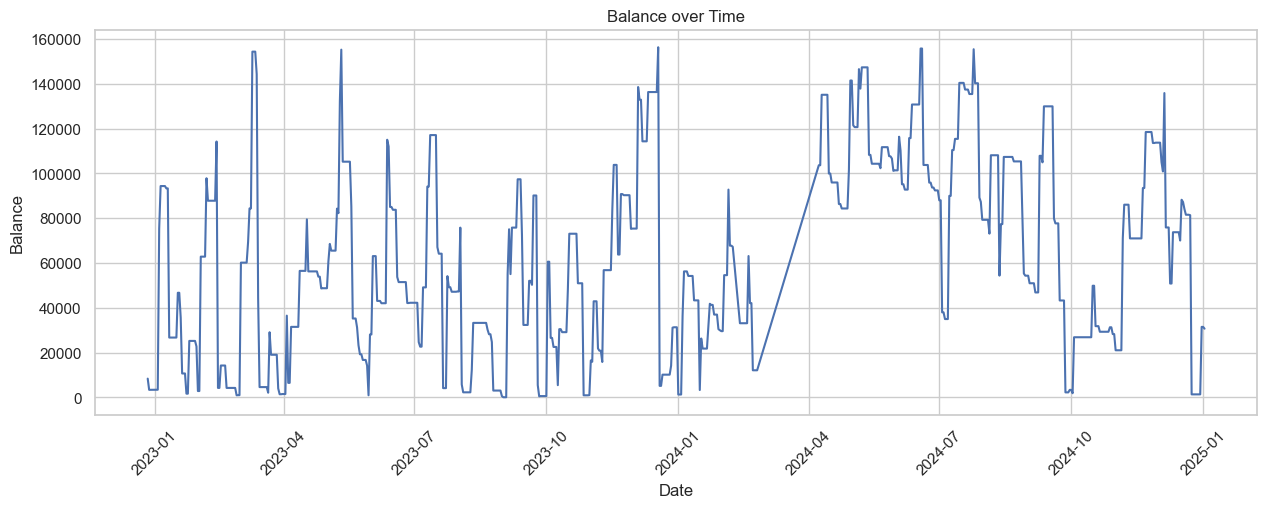

In [27]:
#plot the data
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))
plt.plot(df_balance['Date'], df_balance['Balance'])
plt.title('Balance over Time')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.xticks(rotation=45)
plt.show()


In [28]:
min_val=df_balance['Balance'].min()
print(min_val)

85.18


In [29]:
max_val=df_balance['Balance'].max()
print(max_val)

156354.92


In [30]:
df_balance['Normalized_Balance'] = (df_balance['Balance'] - min_val) / (max_val - min_val)

In [31]:
print(df_balance.head())

        Date  Balance  Normalized_Balance
0 2022-12-27  8399.35            0.053204
1 2022-12-28  3399.35            0.021208
2 2022-12-29  3399.35            0.021208
3 2022-12-30  3440.92            0.021474
4 2022-12-31  3440.92            0.021474


In [32]:
df_final=df_balance[['Date','Normalized_Balance']].copy()

In [33]:
print(df_final.head())

        Date  Normalized_Balance
0 2022-12-27            0.053204
1 2022-12-28            0.021208
2 2022-12-29            0.021208
3 2022-12-30            0.021474
4 2022-12-31            0.021474


In [34]:
#get this data into a excel file
df_final.to_excel("n_beats_shihara_balance.xlsx",index=False)